In [3]:
import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.balance import infer_couples
from microbial_thermo.figures import plot_energy_explorer, plot_half_reactions, plot_redox_tower
from microbial_thermo.supplemental import supplemental_species
entry = supplemental_species()["NH2OH(aq)"]

In [4]:
EQUATION = "NO3- + H2 -> NH2OH"
conditions = mt.Conditions(temperature_c=25.0, pH=4)
reaction = mt.Reaction.from_equation(EQUATION, conditions=conditions)
print(reaction.summary())

Reaction:  1/3 H+ + H2(aq) + 1/3 NO3- -> 1/3 NH2OH(aq) + 2/3 H2O
  donor     H+/H2(aq)  (oxidative)  E0' = -0.328 V
  acceptor  NO3-/NH2OH(aq)  (reductive)  E0' = +0.392 V
  n electrons        2
  dE0'               +0.721 V
  dG0'               -139.1 kJ/mol
  dG (conditions)    -139.1 kJ/mol
  dG per electron    -69.5 kJ/mol e-


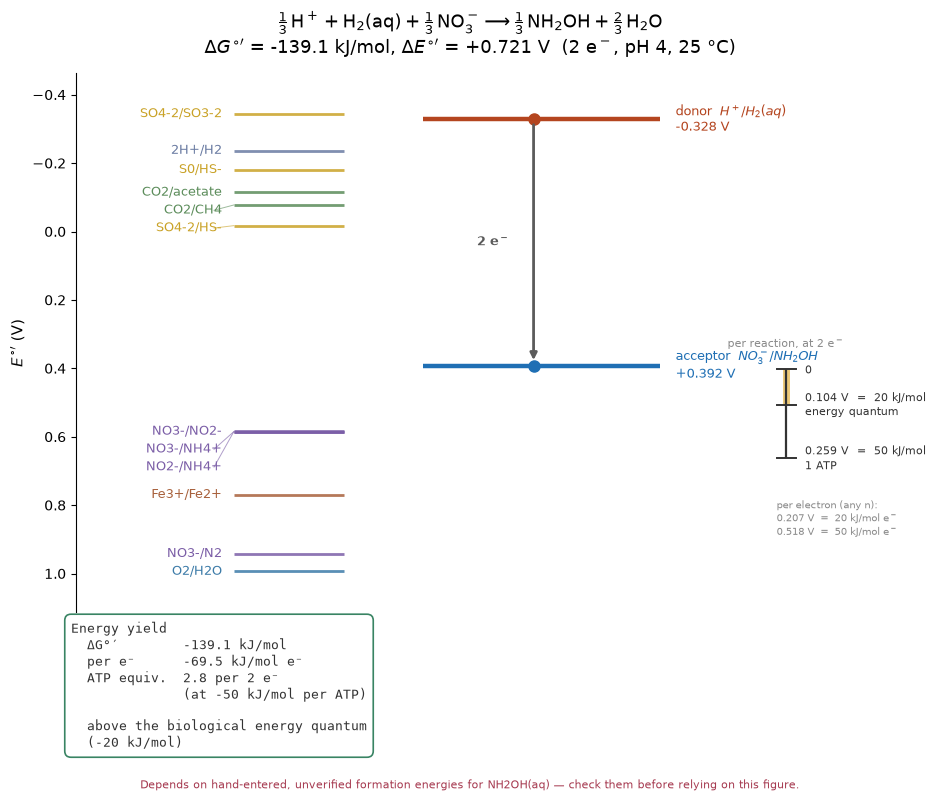

In [8]:
p = plot_redox_tower(reaction)

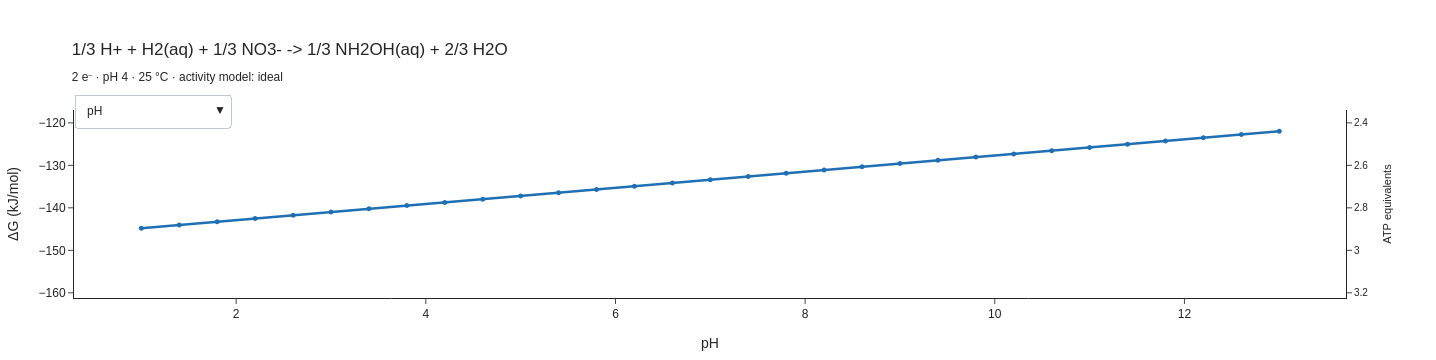

In [7]:
from microbial_thermo.sweep import concentration_axis, partial_pressure_axis, ph_axis

axes = [
    ph_axis(low=1.0, high=13.0, n=31),
    concentration_axis("NO3-"),
    concentration_axis("NH2OH(aq)"),
    partial_pressure_axis("H2(aq)"),
]
figure = plot_energy_explorer(reaction, axes=axes)

figure.show()